In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import cohen_kappa_score, mean_absolute_error, r2_score, classification_report, confusion_matrix
from mord import LogisticAT
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [21]:
df = pd.read_csv('../../data/clean/clean_public_data.csv')

In [22]:
# Convert target column to numeric
energy_classes = {
    'A4': 0,
    'A3': 1,
    'A2': 2,
    'A1': 3,
    'B': 4,
    'C': 5,
    'D': 6,
    'E': 7,
    'F': 8,
    'G': 9
}
df['classe_energetica'] = df['classe_energetica'].map(energy_classes).astype(int)

In [23]:
df.head()

,epglnren,sup_riscaldata,sup_raffrescata,vol_riscaldato,vol_raffrescato,sup_disperdente,rapsv,asolsut,classe_energetica,presenza_clim_invernale,presenza_clim_estiva,presenza_produzione_acs,yie,anno_costruzione,zona_climatica,d_uso_Residenziale,tipologia_edilizia,tipologia_costruttiva,num_servizi,efficienza_media,potenza_tot,num_simulati,construction_era,piano,tip_edilizia_sq,zona_clim_num,zona_clim_gg_mid
0,196.28,210.07,0.00,865.20,0.00,540.37,0.6246,0.0503,8,True,False,True,0.1794,1946-1960,D,True,1,muratura portante,2,0.835000,54.80,0,1,multi_floor,1,4,1750
1,193.17,72.29,72.29,261.13,261.13,176.77,0.6769,0.0550,7,True,True,True,0.1560,1992-2005,D,True,5,c.a. con laterizi,3,0.600000,29.62,0,3,ground,25,4,1750
2,173.49,47.90,0.00,202.85,0.00,108.34,0.5341,0.0412,9,True,False,True,0.2196,before 1930,E,True,3,muratura portante,2,0.515000,1.50,1,1,ground,9,5,2550
3,177.51,60.00,60.00,217.08,217.08,171.90,0.7918,0.0340,6,True,True,True,0.5410,1961-1975,D,True,8,legno,3,0.716667,13.00,0,1,underground,64,4,1750
4,173.88,194.01,0.00,785.11,0.00,523.24,0.6665,0.0692,8,True,False,True,0.1252,before 1930,E,True,1,muratura portante,2,0.790000,48.20,0,1,multi_floor,1,5,2550


### Define X and y, then preprocess

In [24]:
X = df.drop(columns=['epglnren', 'classe_energetica'])

In [25]:
y = df['classe_energetica']

In [26]:
# Column transformer
numerical_features = X.select_dtypes(include=['int64', 'float64', 'bool']).columns
categorical_features = X.select_dtypes(include=['object', 'category', 'str']).columns

print(f'features excluding target variable: {len(X.columns)}')
print(f'numerical features: {len(numerical_features)}')
print(f'categorical features: {len(categorical_features)}')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", categorical_transformer, categorical_features),
        ("StandardScaler", numeric_transformer, numerical_features)
    ]
)

features excluding target variable: 25
numerical features: 21
categorical features: 4


In [27]:
X = preprocessor.fit_transform(X)

In [29]:
X.shape

(8882, 52)

In [30]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((7105, 52), (1777, 52))

### Create an evaluation function to present all metrics after model training

In [31]:
def evaluate_model(true, predicted):

    kappa = cohen_kappa_score(true, predicted, weights='quadratic')
    rmse = np.sqrt(mean_absolute_error(true, predicted))
    r2 = r2_score(true, predicted)

    return kappa, rmse, r2

In [32]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

models = {
    'LogisticAT': LogisticAT(),
    'CatBoostClassifier': CatBoostClassifier(verbose=0, iterations=500),
    'LGBMClassifier': LGBMClassifier(verbose=-1),
    'XGBClassifier': xgb.XGBClassifier(use_label_encoder=False, verbosity=0, enable_categorical=True),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=100, n_jobs=-1),
    'GradientBoostingClassifier': GradientBoostingClassifier(n_estimators=100),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(max_depth=10),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'ExtraTreesClassifier': ExtraTreesClassifier(),
    'SVC': SVC(kernel='rbf'),
}
model_results = []
kappa_scores = []

for i in range(len(list(models))):

    model = list(models.values())[i]
    model.fit(X_train, y_train) # train the model

    # make predictions
    y_train_pred = model.predict(X_train) 
    y_test_pred = model.predict(X_test)

    # evaluate model performance
    model_train_kappa, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_kappa, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_results.append(list(models.keys())[i])

    print('\nModel performance on training set:')
    print(f'  Kappa: {model_train_kappa:.4f}')
    print(f'  RMSE: {model_train_rmse:.4f}')
    print(f'  R2: {model_train_r2:.4f}')
    print ('---' * 10)
    print('Model performance on test set:')
    print(f'  Kappa: {model_test_kappa:.4f}')
    print(f'  RMSE: {model_test_rmse:.4f}')
    print(f'  R2: {model_test_r2:.4f}')
    
    kappa_scores.append(model_test_kappa)

    print('=' * 20)
    print('\n')


LogisticAT

Model performance on training set:
  Kappa: 0.6419
  RMSE: 0.9818
  R2: 0.4511
------------------------------
Model performance on test set:
  Kappa: 0.6908
  RMSE: 0.9492
  R2: 0.5174


CatBoostClassifier

Model performance on training set:
  Kappa: 0.9551
  RMSE: 0.4244
  R2: 0.9103
------------------------------
Model performance on test set:
  Kappa: 0.7797
  RMSE: 0.8658
  R2: 0.5830




c:\Users\AmirN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\AmirN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier

Model performance on training set:
  Kappa: 0.9833
  RMSE: 0.3071
  R2: 0.9664
------------------------------
Model performance on test set:
  Kappa: 0.7659
  RMSE: 0.8774
  R2: 0.5705


XGBClassifier

Model performance on training set:
  Kappa: 0.9914
  RMSE: 0.2089
  R2: 0.9827
------------------------------
Model performance on test set:
  Kappa: 0.7527
  RMSE: 0.8989
  R2: 0.5300


RandomForestClassifier

Model performance on training set:
  Kappa: 1.0000
  RMSE: 0.0000
  R2: 1.0000
------------------------------
Model performance on test set:
  Kappa: 0.7447
  RMSE: 0.8901
  R2: 0.5306


GradientBoostingClassifier

Model performance on training set:
  Kappa: 0.8620
  RMSE: 0.7167
  R2: 0.7280
------------------------------
Model performance on test set:
  Kappa: 0.7351
  RMSE: 0.9264
  R2: 0.4846


KNeighborsClassifier

Model performance on training set:
  Kappa: 0.7410
  RMSE: 0.8545
  R2: 0.4823
------------------------------
Model performance on test set:
  Kapp

In [34]:
pd.DataFrame(list(zip(model_results, kappa_scores)), columns=['Model', 'Kappa Score']).sort_values(by='Kappa Score', ascending=False)

,Model,Kappa Score
1,CatBoostClassifier,0.779684
2,LGBMClassifier,0.765900
3,XGBClassifier,0.752697
4,RandomForestClassifier,0.744744
5,GradientBoostingClassifier,0.735148
9,ExtraTreesClassifier,0.716772
10,SVC,0.716198
7,DecisionTreeClassifier,0.700165
0,LogisticAT,0.690782
6,KNeighborsClassifier,0.663715


### It seems the model that understands our data the most is catboost

In [ ]:
cat_model = CatBoostClassifier(verbose=0, iterations=500)
cat_model.fit(X_train, y_train)
y_test_pred = cat_model.predict(X_test)

              precision    recall  f1-score   support

           0       0.55      0.53      0.54        30
           1       0.80      0.21      0.33        19
           2       0.36      0.57      0.44        28
           3       0.40      0.12      0.18        51
           4       0.27      0.25      0.26        55
           5       0.33      0.24      0.28       103
           6       0.28      0.32      0.30       187
           7       0.43      0.40      0.41       359
           8       0.50      0.56      0.53       501
           9       0.66      0.70      0.68       444

    accuracy                           0.49      1777
   macro avg       0.46      0.39      0.40      1777
weighted avg       0.49      0.49      0.48      1777



### Verify with Confusion Matrix

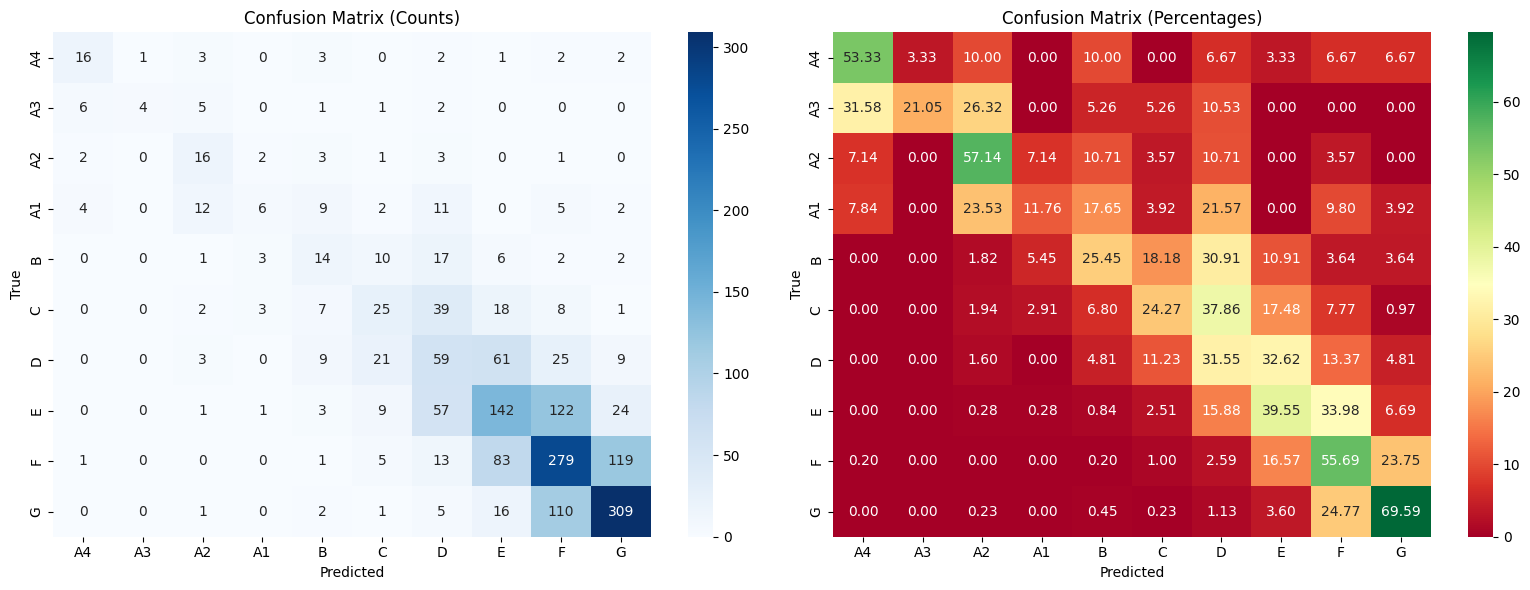

In [39]:
cm = confusion_matrix(y_test, y_test_pred, labels=range(10))
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A4','A3','A2','A1','B','C','D','E','F','G'],
            yticklabels=['A4','A3','A2','A1','B','C','D','E','F','G'], ax=ax1)
ax1.set_title('Confusion Matrix (Counts)') # plot for raw counts
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')


sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=['A4','A3','A2','A1','B','C','D','E','F','G'],
            yticklabels=['A4','A3','A2','A1','B','C','D','E','F','G'], ax=ax2)
ax2.set_title('Confusion Matrix (Percentages)') # plot for percentages
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.tight_layout()
plt.show()